# Classification Tree Analysis - Supermarkets Data
Classification tree to predict supermarket brand (Migros vs Volg) based on location and demographic features.

In [33]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [34]:
# Load supermarkets data
df_supermarkets = pd.read_csv('supermarkets_data_enriched.csv', index_col=0)
print(f"Data shape: {df_supermarkets.shape}")
print(f"\nFirst few rows:")
print(df_supermarkets.head())
print(f"\nData types:\n{df_supermarkets.dtypes}")
print(f"\nMissing values:\n{df_supermarkets.isnull().sum()}")

Data shape: (3242, 17)

First few rows:
   type          id        lat       lon   brand         shop addr:city  \
0  node    33126515  47.155616  9.037915    Spar  supermarket       NaN   
1  node   280130028  47.155492  9.039666    ALDI  supermarket   Schänis   
2  node  6122906632  47.158959  9.044477  Denner  supermarket   Schänis   
3  node  9019298862  47.155185  9.038472    Lidl  supermarket       NaN   
4  node    36726161  47.226191  8.980329  Migros  supermarket    Uznach   

  addr:housenumber  addr:postcode                      geometry  index_right  \
0              NaN            NaN  POINT (9.0379152 47.1556157)          227   
1                3         8718.0  POINT (9.0396663 47.1554921)          227   
2               14         8718.0  POINT (9.0444769 47.1589589)          227   
3              NaN            NaN  POINT (9.0384722 47.1551854)          227   
4               25         8730.0  POINT (8.9803292 47.2261912)         1217   

  bfs_name  bfs_number   pop

## Data Cleaning - Remove Missing Values

In [35]:
# Remove all missing values
df_supermarkets = df_supermarkets.dropna()
print(f"Data shape after removing missing values: {df_supermarkets.shape}")
print(f"Missing values remaining: {df_supermarkets.isnull().sum().sum()}")

Data shape after removing missing values: (917, 17)
Missing values remaining: 0


## Create Subset - Migros and Volg Only

In [36]:
# Create subset with only Migros and Volg
df_sub = df_supermarkets.loc[df_supermarkets['brand'].isin(['Migros', 'Volg'])]
print(f"Subset shape: {df_sub.shape}")
print(f"\nBrand distribution in subset:")
print(df_sub['brand'].value_counts())

Subset shape: (403, 17)

Brand distribution in subset:
brand
Migros    335
Volg       68
Name: count, dtype: int64


## Prepare Features and Target

In [37]:
# Define feature variables and target variable
feature_cols = ['lat', 'lon', 'pop', 'pop_dens', 'frg_pct', 'emp']
X = df_sub[feature_cols]
y = df_sub['brand']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"\nFeature statistics:")
print(X.describe())

Features shape: (403, 6)
Target shape: (403,)

Feature columns: ['lat', 'lon', 'pop', 'pop_dens', 'frg_pct', 'emp']

Feature statistics:
              lat         lon            pop      pop_dens     frg_pct  \
count  403.000000  403.000000     403.000000    403.000000  403.000000   
mean    47.200020    8.240109   54227.801489   1674.685773   25.235972   
std      0.367733    0.722631  106880.213291   1943.731097    9.250548   
min     45.845224    6.126280     375.000000      4.246455    4.727921   
25%     47.047592    7.619638    5254.000000    400.157153   19.008940   
50%     47.316793    8.380678   11861.000000    966.548673   24.862732   
75%     47.459082    8.706538   29303.000000   2189.323579   32.083637   
max     47.748807    9.832611  420217.000000  12810.992462   54.808906   

                 emp  
count     403.000000  
mean    56676.945409  
std    125755.076585  
min       185.000000  
25%      2254.000000  
50%      6582.000000  
75%     23967.000000  
max    49119

## Create Train/Test Split

In [38]:
# Split data into train/test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 322 (79.9%)
Test set size: 81 (20.1%)

Training set target distribution:
brand
Migros    268
Volg       54
Name: count, dtype: int64

Test set target distribution:
brand
Migros    67
Volg      14
Name: count, dtype: int64


## Train Classification Tree Model

In [39]:
# Fit the decision tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred_train = dt_classifier.predict(X_train)
y_pred_test = dt_classifier.predict(X_test)

# Get prediction probabilities for ROC curve
y_pred_proba = dt_classifier.predict_proba(X_test)

print("Model trained successfully!")
print(f"Training accuracy: {dt_classifier.score(X_train, y_train):.4f}")
print(f"Test accuracy: {dt_classifier.score(X_test, y_test):.4f}")

Model trained successfully!
Training accuracy: 1.0000
Test accuracy: 0.7901


## Text Representation of the Classification Tree

In [40]:
# Print text representation of the tree
tree_rules = export_text(dt_classifier, feature_names=feature_cols)
print("Decision Tree Rules:")
print(tree_rules)

Decision Tree Rules:
|--- pop <= 3661.00
|   |--- frg_pct <= 17.70
|   |   |--- emp <= 1659.50
|   |   |   |--- lat <= 46.41
|   |   |   |   |--- pop_dens <= 49.97
|   |   |   |   |   |--- class: Volg
|   |   |   |   |--- pop_dens >  49.97
|   |   |   |   |   |--- class: Migros
|   |   |   |--- lat >  46.41
|   |   |   |   |--- class: Volg
|   |   |--- emp >  1659.50
|   |   |   |--- lon <= 7.82
|   |   |   |   |--- class: Volg
|   |   |   |--- lon >  7.82
|   |   |   |   |--- class: Migros
|   |--- frg_pct >  17.70
|   |   |--- pop <= 2195.00
|   |   |   |--- lat <= 46.41
|   |   |   |   |--- class: Migros
|   |   |   |--- lat >  46.41
|   |   |   |   |--- class: Volg
|   |   |--- pop >  2195.00
|   |   |   |--- frg_pct <= 30.43
|   |   |   |   |--- pop_dens <= 113.68
|   |   |   |   |   |--- class: Volg
|   |   |   |   |--- pop_dens >  113.68
|   |   |   |   |   |--- class: Migros
|   |   |   |--- frg_pct >  30.43
|   |   |   |   |--- class: Volg
|--- pop >  3661.00
|   |--- frg_pct 

## Visualize the Classification Tree

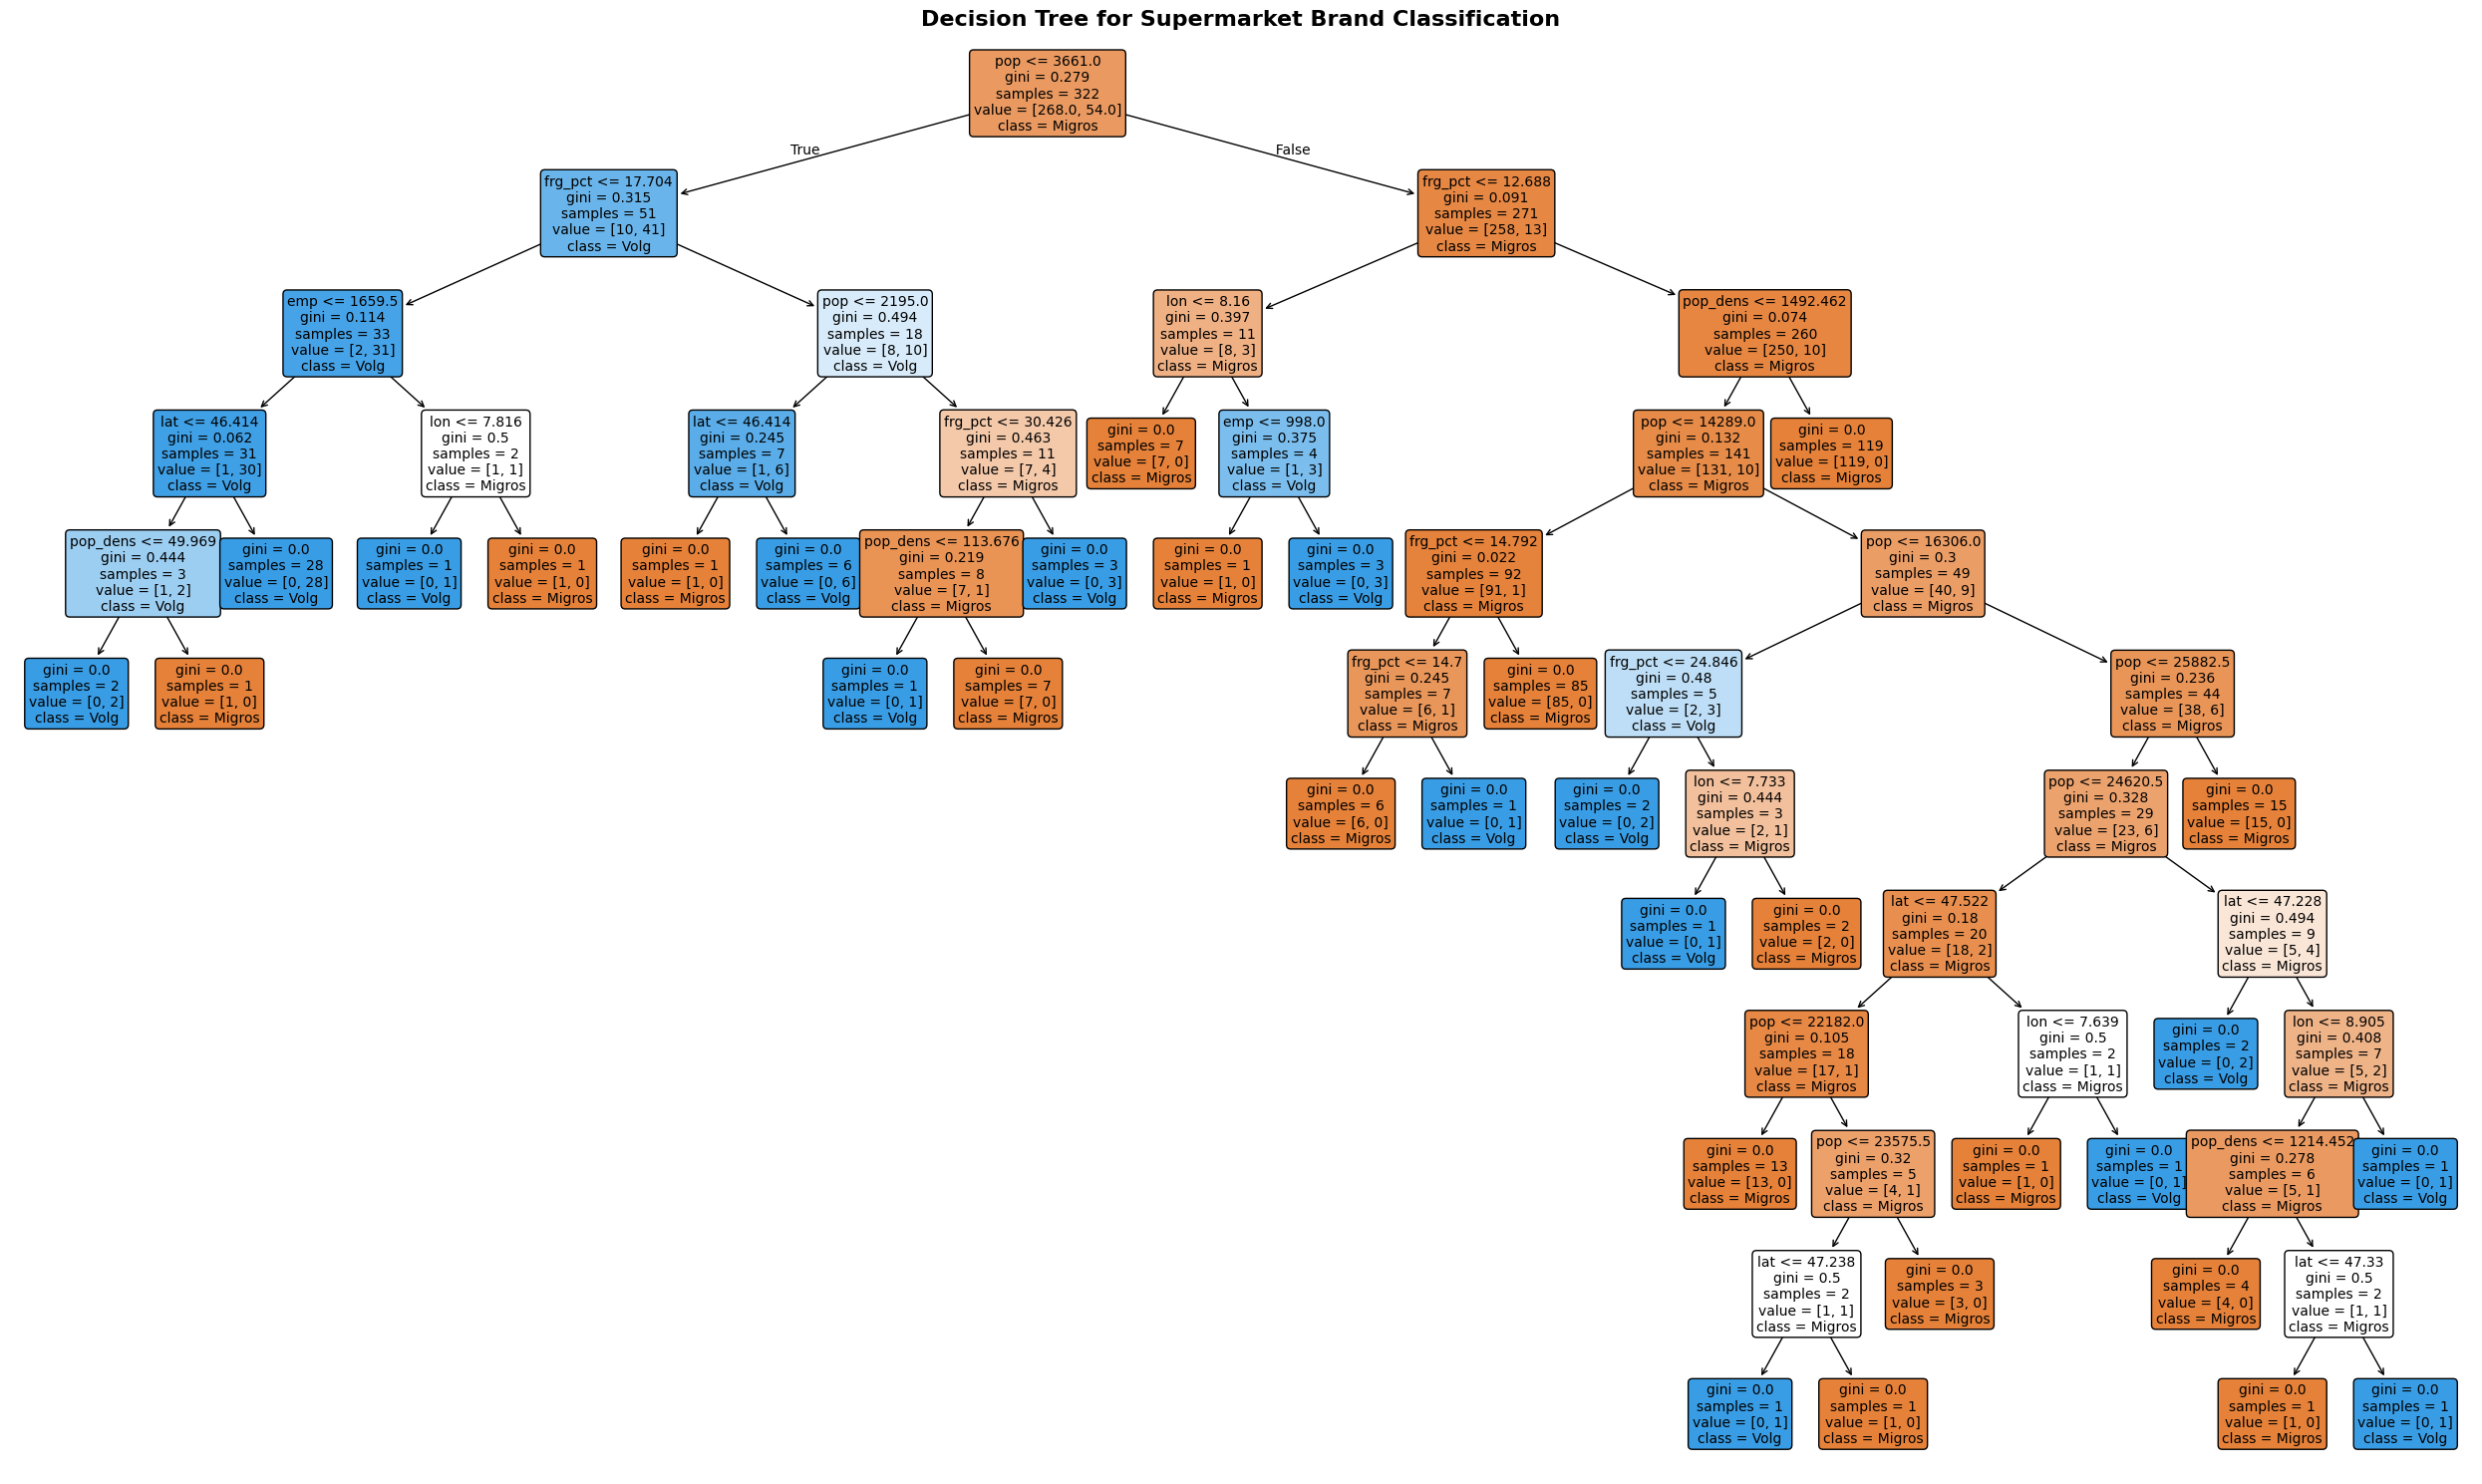

In [41]:
# Visualize the tree
plt.figure(figsize=(25, 15))
plot_tree(dt_classifier, 
          feature_names=feature_cols,
          class_names=['Migros', 'Volg'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Supermarket Brand Classification", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Confusion Matrix and Classification Report

In [42]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm)
print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {cm[0, 0]} (correctly predicted Migros)")
print(f"False Positives (FP): {cm[0, 1]} (incorrectly predicted Volg as Migros)")
print(f"False Negatives (FN): {cm[1, 0]} (incorrectly predicted Migros as Volg)")
print(f"True Positives (TP): {cm[1, 1]} (correctly predicted Volg)")

# Print classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=['Migros', 'Volg']))

Confusion Matrix:
[[57 10]
 [ 7  7]]

Confusion Matrix Interpretation:
True Negatives (TN): 57 (correctly predicted Migros)
False Positives (FP): 10 (incorrectly predicted Volg as Migros)
False Negatives (FN): 7 (incorrectly predicted Migros as Volg)
True Positives (TP): 7 (correctly predicted Volg)

Classification Report:
              precision    recall  f1-score   support

      Migros       0.89      0.85      0.87        67
        Volg       0.41      0.50      0.45        14

    accuracy                           0.79        81
   macro avg       0.65      0.68      0.66        81
weighted avg       0.81      0.79      0.80        81



## ROC Curve and AUC

AUC Score: 0.6754


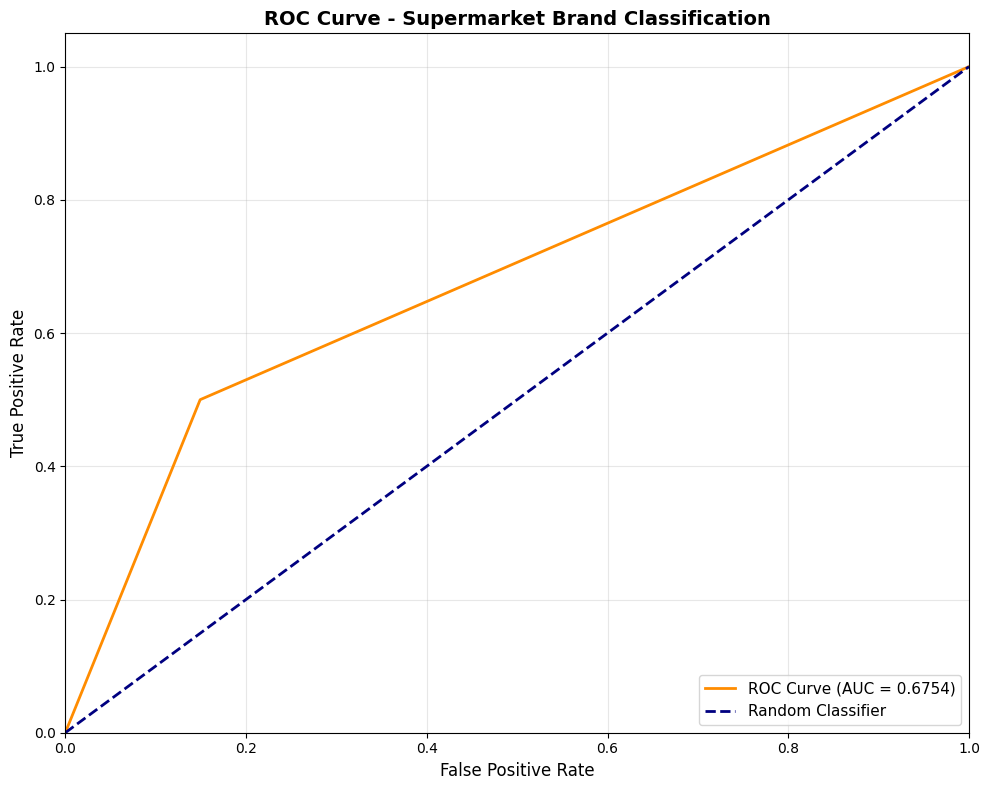


Interpretation: AUC = 0.6754
Poor discrimination between classes


In [43]:
# Encode target variable for ROC curve (binary: 0 for Migros, 1 for Volg)
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Supermarket Brand Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nInterpretation: AUC = {roc_auc:.4f}")
if roc_auc >= 0.9:
    print("Excellent discrimination between classes")
elif roc_auc >= 0.8:
    print("Good discrimination between classes")
elif roc_auc >= 0.7:
    print("Fair discrimination between classes")
elif roc_auc >= 0.6:
    print("Poor discrimination between classes")
else:
    print("Very poor discrimination between classes")

## Random Forest Classifier Analysis

### Create Train/Test Split for Random Forest

In [44]:
# Create train/test split for Random Forest using df_sub
X2 = df_sub[feature_cols]
y2 = df_sub['brand']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f"Random Forest Train/Test Split:")
print(f"Training set size: {X2_train.shape[0]} ({X2_train.shape[0]/len(X2)*100:.1f}%)")
print(f"Test set size: {X2_test.shape[0]} ({X2_test.shape[0]/len(X2)*100:.1f}%)")
print(f"\nTraining set target distribution:")
print(y2_train.value_counts())
print(f"\nTest set target distribution:")
print(y2_test.value_counts())

Random Forest Train/Test Split:
Training set size: 322 (79.9%)
Test set size: 81 (20.1%)

Training set target distribution:
brand
Migros    268
Volg       54
Name: count, dtype: int64

Test set target distribution:
brand
Migros    67
Volg      14
Name: count, dtype: int64


### Fit Random Forest Classifier

In [45]:
# Fit the random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X2_train, y2_train)

# Make predictions
y2_pred_train = rf_classifier.predict(X2_train)
y2_pred_test = rf_classifier.predict(X2_test)

# Get prediction probabilities for ROC curve
y2_pred_proba = rf_classifier.predict_proba(X2_test)

print("Random Forest Model trained successfully!")
print(f"Training accuracy: {rf_classifier.score(X2_train, y2_train):.4f}")
print(f"Test accuracy: {rf_classifier.score(X2_test, y2_test):.4f}")

Random Forest Model trained successfully!
Training accuracy: 1.0000
Test accuracy: 0.9012


### Confusion Matrix and Classification Report for Random Forest

In [46]:
# Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y2_test, y2_pred_test)
print("Random Forest Confusion Matrix:")
print(cm_rf)
print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {cm_rf[0, 0]} (correctly predicted Migros)")
print(f"False Positives (FP): {cm_rf[0, 1]} (incorrectly predicted Volg as Migros)")
print(f"False Negatives (FN): {cm_rf[1, 0]} (incorrectly predicted Migros as Volg)")
print(f"True Positives (TP): {cm_rf[1, 1]} (correctly predicted Volg)")

# Print classification report
print("\n" + "="*60)
print("Random Forest Classification Report:")
print("="*60)
print(classification_report(y2_test, y2_pred_test, target_names=['Migros', 'Volg']))

Random Forest Confusion Matrix:
[[65  2]
 [ 6  8]]

Confusion Matrix Interpretation:
True Negatives (TN): 65 (correctly predicted Migros)
False Positives (FP): 2 (incorrectly predicted Volg as Migros)
False Negatives (FN): 6 (incorrectly predicted Migros as Volg)
True Positives (TP): 8 (correctly predicted Volg)

Random Forest Classification Report:
              precision    recall  f1-score   support

      Migros       0.92      0.97      0.94        67
        Volg       0.80      0.57      0.67        14

    accuracy                           0.90        81
   macro avg       0.86      0.77      0.80        81
weighted avg       0.90      0.90      0.89        81

              precision    recall  f1-score   support

      Migros       0.92      0.97      0.94        67
        Volg       0.80      0.57      0.67        14

    accuracy                           0.90        81
   macro avg       0.86      0.77      0.80        81
weighted avg       0.90      0.90      0.89      

### Feature Importance in Random Forest

Feature Importance:
    Feature  Importance
2       pop    0.276939
5       emp    0.252106
3  pop_dens    0.154099
4   frg_pct    0.127509
0       lat    0.096214
1       lon    0.093132


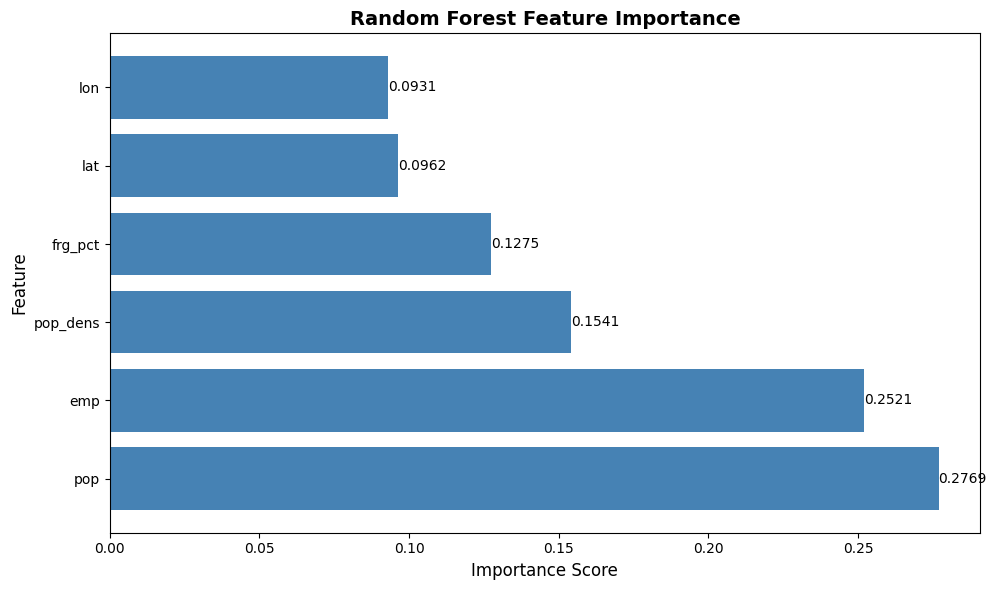

In [47]:
# Get feature importance
feature_importance = rf_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             ha='left', va='center', fontsize=10)

plt.show()

### ROC Curve and AUC for Random Forest

Random Forest AUC Score: 0.8763


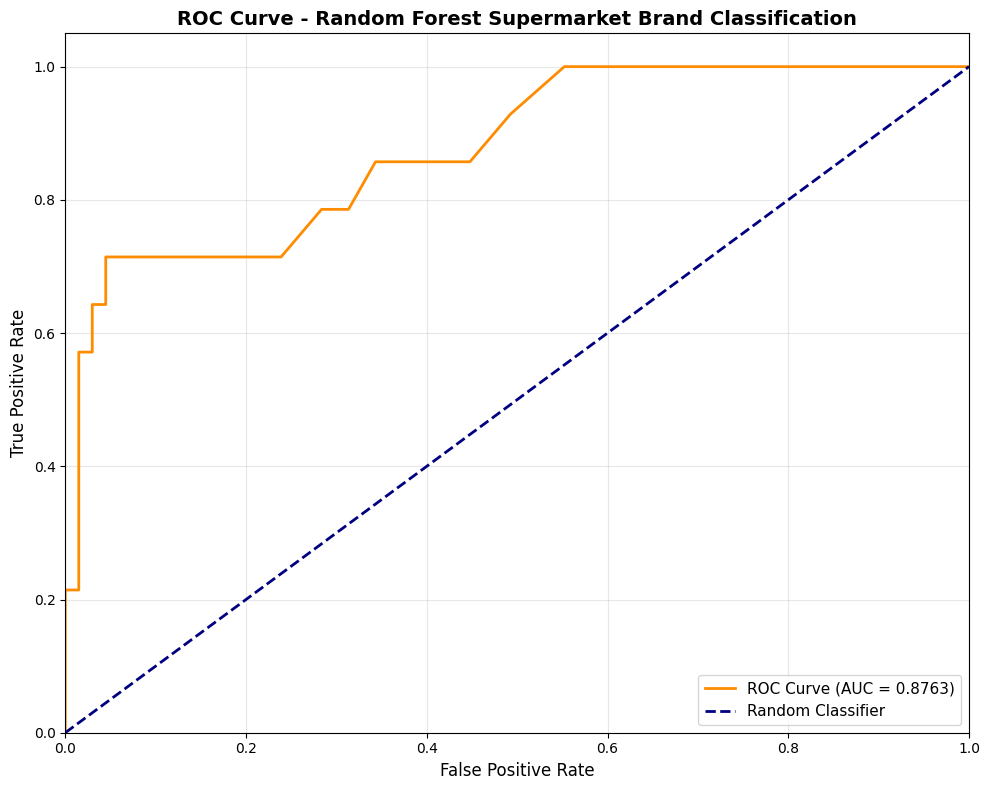


Interpretation: AUC = 0.8763
Good discrimination between classes


In [48]:
# Encode target variable for ROC curve (binary: 0 for Migros, 1 for Volg)
le_rf = LabelEncoder()
y2_test_encoded = le_rf.fit_transform(y2_test)

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y2_test_encoded, y2_pred_proba[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

print(f"Random Forest AUC Score: {roc_auc_rf:.4f}")

# Plot ROC curve for Random Forest
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest Supermarket Brand Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nInterpretation: AUC = {roc_auc_rf:.4f}")
if roc_auc_rf >= 0.9:
    print("Excellent discrimination between classes")
elif roc_auc_rf >= 0.8:
    print("Good discrimination between classes")
elif roc_auc_rf >= 0.7:
    print("Fair discrimination between classes")
elif roc_auc_rf >= 0.6:
    print("Poor discrimination between classes")
else:
    print("Very poor discrimination between classes")